# Mobile Price Prediction — Experiments

This notebook implements the end-to-end workflow described in the project README:

1. Understand and load the dataset
2. Check missing values and duplicate records
3. Perform exploratory data analysis
4. Split data into training and testing sets
5. Train classification models
6. Evaluate Accuracy, Precision, Recall, F1-score and Confusion Matrix
7. Generate predictions
8. Save the trained Random Forest model
9. Test the saved model with a new mobile-phone input

**Target:** `price_range`

**Classes:**  
0 = Low Price  
1 = Medium Price  
2 = High Price  
3 = Very High Price

The project README specifies **Random Forest Classifier** as the main model and the saved model path as `models/mobile_price_model.pkl`.

In [12]:
# Imports
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

RANDOM_STATE = 42

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Project paths

The notebook expects the dataset at:

`data/raw/train.csv`

If your `train.csv` is stored somewhere else, change `DATA_PATH` below.

In [13]:
# Project paths
from pathlib import Path

candidate_roots = [
    Path.cwd(),
    *Path.cwd().parents,
    Path.home() / "OneDrive" / "Desktop" / "Mobile_price_prediction",
    Path.home() / "Desktop" / "Mobile_price_prediction",
]
PROJECT_ROOT = next(
    (path for path in candidate_roots if (path / "data" / "raw" / "train.csv").exists()),
    None,
)

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not find data/raw/train.csv. Set PROJECT_ROOT to the project directory."
    )

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "train.csv"
MODEL_DIR = PROJECT_ROOT / "models"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
REPORT_DIR = PROJECT_ROOT / "reports"

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

print("Project directory:", PROJECT_ROOT)
print("Dataset path:", DATA_PATH)
print("Model directory:", MODEL_DIR)
print("Output directory:", OUTPUT_DIR)

Project directory: C:\Users\vecha\OneDrive\Desktop\Mobile_price_prediction
Dataset path: C:\Users\vecha\OneDrive\Desktop\Mobile_price_prediction\data\raw\train.csv
Model directory: C:\Users\vecha\OneDrive\Desktop\Mobile_price_prediction\models
Output directory: C:\Users\vecha\OneDrive\Desktop\Mobile_price_prediction\outputs


In [14]:
# Load dataset
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Dataset not found at: {DATA_PATH}\n"
        "Place train.csv inside data/raw/ or update DATA_PATH."
    )

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)
display(df.head())

Dataset loaded successfully.
Shape: (2000, 21)


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [15]:
# Dataset information
print("Column names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nDataset information:")
df.info()

Column names:
['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g', 'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height', 'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g', 'touch_screen', 'wifi', 'price_range']

Data types:


,dtype
battery_power,int64
blue,int64
clock_speed,float64
dual_sim,int64
fc,int64
four_g,int64
int_memory,int64
m_dep,float64
mobile_wt,int64
n_cores,int64



Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 1

In [16]:
# Missing values
missing = df.isnull().sum().sort_values(ascending=False)
print("Missing values:")
display(missing.to_frame("missing_values"))

# Duplicate records
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

Missing values:


,missing_values
battery_power,0
blue,0
clock_speed,0
dual_sim,0
fc,0
four_g,0
int_memory,0
m_dep,0
mobile_wt,0
n_cores,0


Duplicate rows: 0


## 2. Exploratory Data Analysis

We inspect the target distribution and the numerical feature distributions before training.

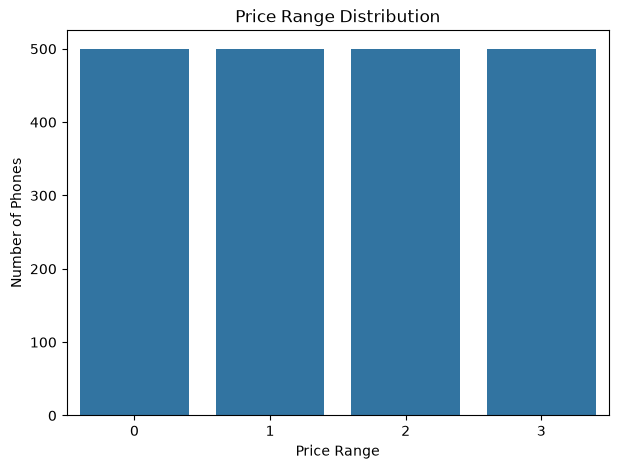

price_range
0    500
1    500
2    500
3    500
Name: count, dtype: int64


In [17]:
# Target distribution
if "price_range" not in df.columns:
    raise KeyError("Target column 'price_range' was not found in the dataset.")

plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="price_range")
plt.title("Price Range Distribution")
plt.xlabel("Price Range")
plt.ylabel("Number of Phones")
plt.show()

print(df["price_range"].value_counts().sort_index())

In [34]:
# Descriptive statistics
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
battery_power,2000.0,1238.51850,439.418206,501.0,851.75,1226.0,1615.25,1998.0
blue,2000.0,0.49500,0.500100,0.0,0.00,0.0,1.00,1.0
clock_speed,2000.0,1.52225,0.816004,0.5,0.70,1.5,2.20,3.0
dual_sim,2000.0,0.50950,0.500035,0.0,0.00,1.0,1.00,1.0
fc,2000.0,4.30950,4.341444,0.0,1.00,3.0,7.00,19.0
four_g,2000.0,0.52150,0.499662,0.0,0.00,1.0,1.00,1.0
int_memory,2000.0,32.04650,18.145715,2.0,16.00,32.0,48.00,64.0
m_dep,2000.0,0.50175,0.288416,0.1,0.20,0.5,0.80,1.0
mobile_wt,2000.0,140.24900,35.399655,80.0,109.00,141.0,170.00,200.0
n_cores,2000.0,4.52050,2.287837,1.0,3.00,4.0,7.00,8.0


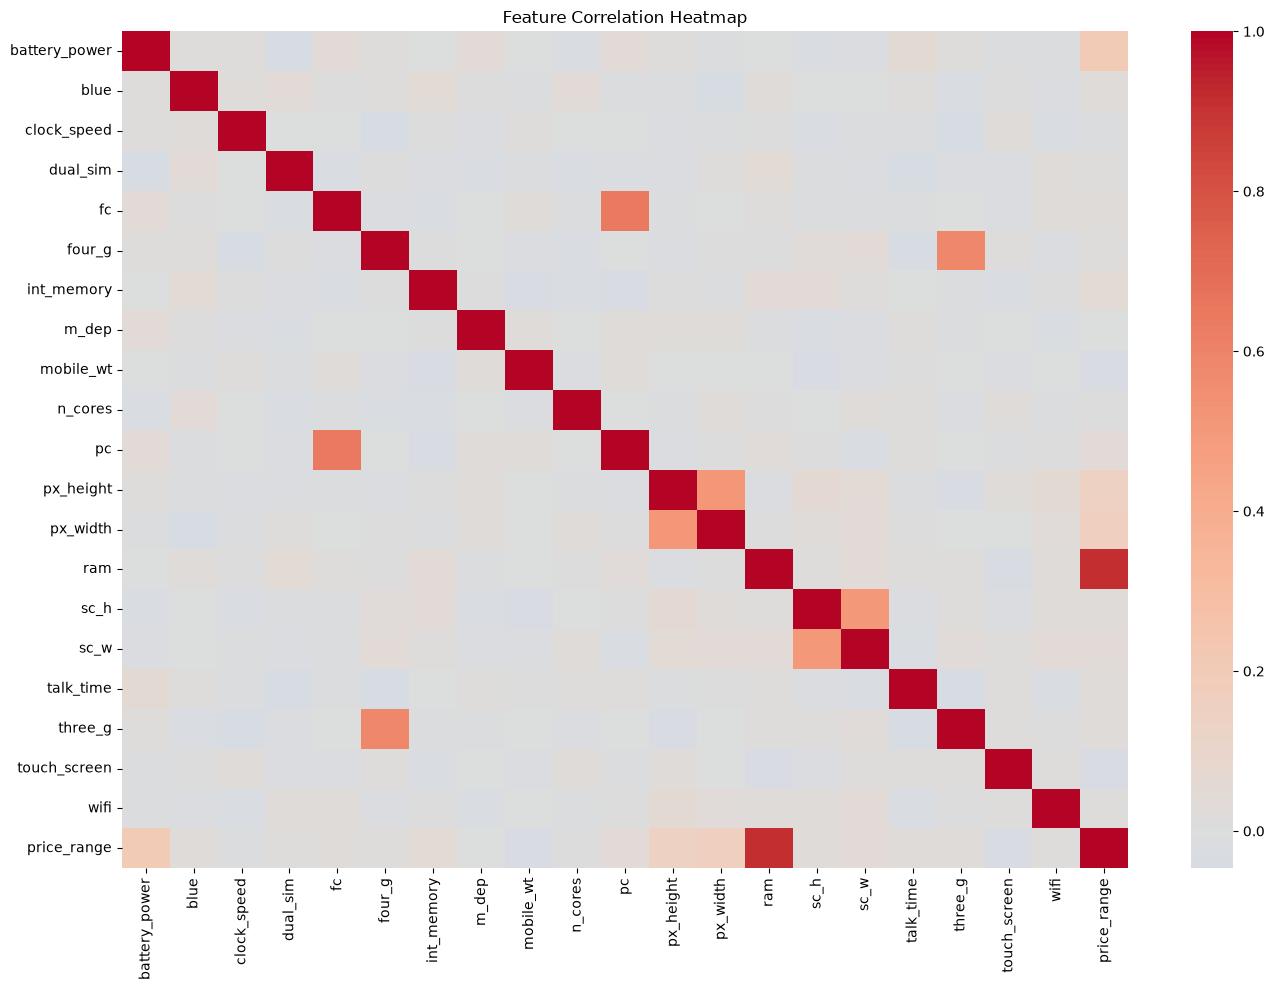

In [35]:
# Correlation heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

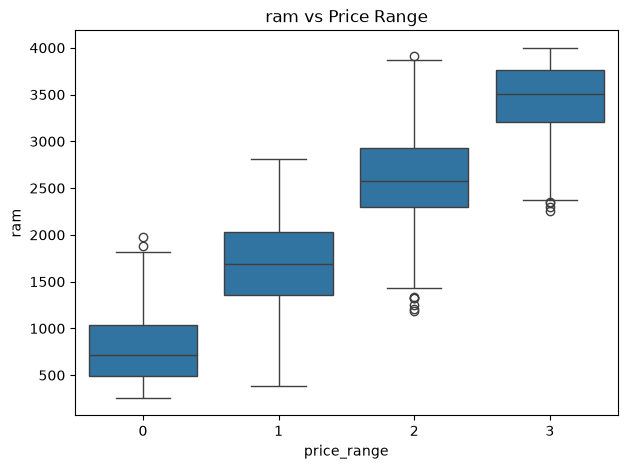

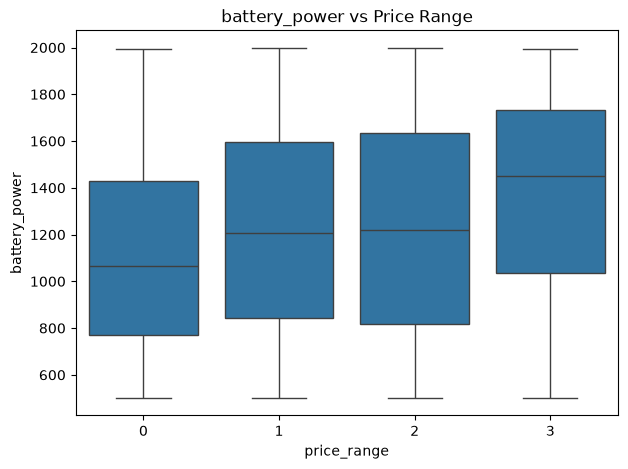

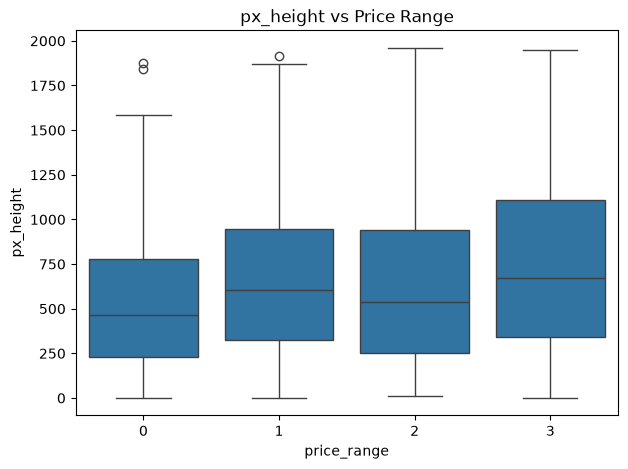

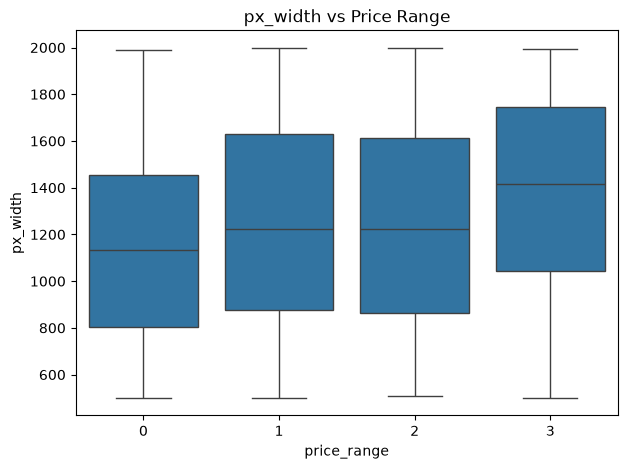

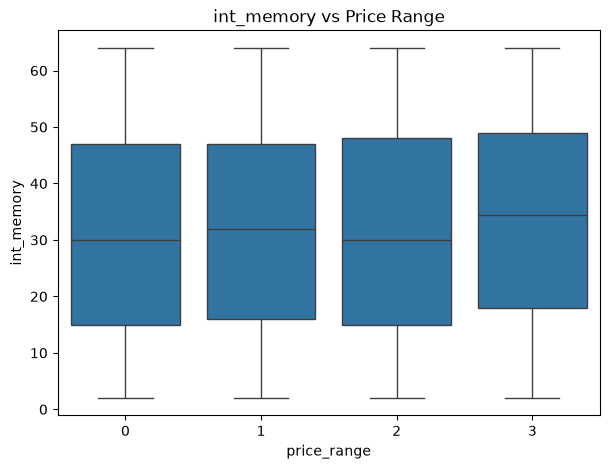

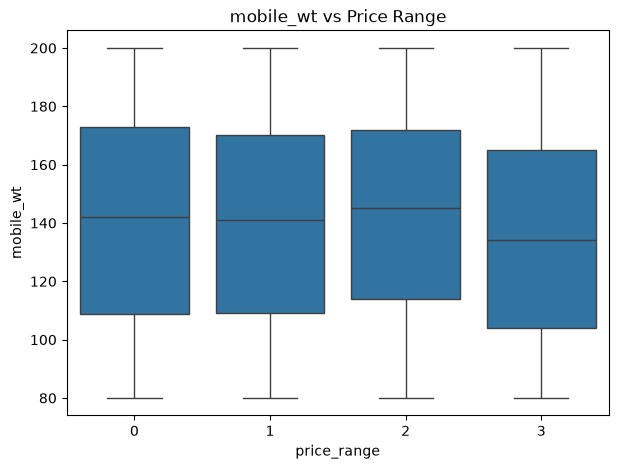

In [20]:
# Useful feature relationships with price range
candidate_features = [c for c in ["ram", "battery_power", "px_height", "px_width", "int_memory", "mobile_wt"] if c in df.columns]

for feature in candidate_features:
    plt.figure(figsize=(7, 5))
    sns.boxplot(data=df, x="price_range", y=feature)
    plt.title(f"{feature} vs Price Range")
    plt.show()

## 3. Prepare the data

`price_range` is the target. All remaining columns are used as input features.

The notebook performs a stratified train-test split so that the four price classes are represented in both sets.

In [21]:
# Separate features and target
X = df.drop(columns=["price_range"])
y = df["price_range"]

print("Features:", X.shape)
print("Target:", y.shape)
print("Target classes:", sorted(y.unique().tolist()))

Features: (2000, 20)
Target: (2000,)
Target classes: [0, 1, 2, 3]


In [22]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (1600, 20)
X_test : (400, 20)
y_train: (1600,)
y_test : (400,)


## 4. Train and compare eight classification models

The notebook compares Logistic Regression, Decision Tree, Random Forest, KNN, SVM, XGBoost, Gradient Boosting and Naive Bayes using the same stratified test split. StandardScaler is applied through pipelines for Logistic Regression, KNN and SVM; tree-based models and Naive Bayes use the original feature values.

Random Forest remains the project's primary saved model.

In [23]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
    ]),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=5, n_jobs=-1))
    ]),
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf"))
    ]),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="multi:softprob",
        num_class=int(y.nunique()),
        eval_metric="mlogloss",
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=RANDOM_STATE
    ),
    "Naive Bayes": GaussianNB()
}

results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_test, y_pred, average="weighted", zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, average="weighted", zero_division=0)
    })

    trained_models[name] = model

results_df = (
    pd.DataFrame(results)
    .sort_values("Accuracy", ascending=False)
    .reset_index(drop=True)
)
display(results_df)

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.9650,0.965045,0.9650,0.964986
1,XGBoost,0.9375,0.937268,0.9375,0.937348
2,Gradient Boosting,0.9125,0.912431,0.9125,0.912295
3,SVM,0.8950,0.896860,0.8950,0.895631
4,Random Forest,0.8800,0.880470,0.8800,0.880180
5,Decision Tree,0.8300,0.831883,0.8300,0.830168
6,Naive Bayes,0.8100,0.811326,0.8100,0.810458
7,KNN,0.5000,0.521130,0.5000,0.505355


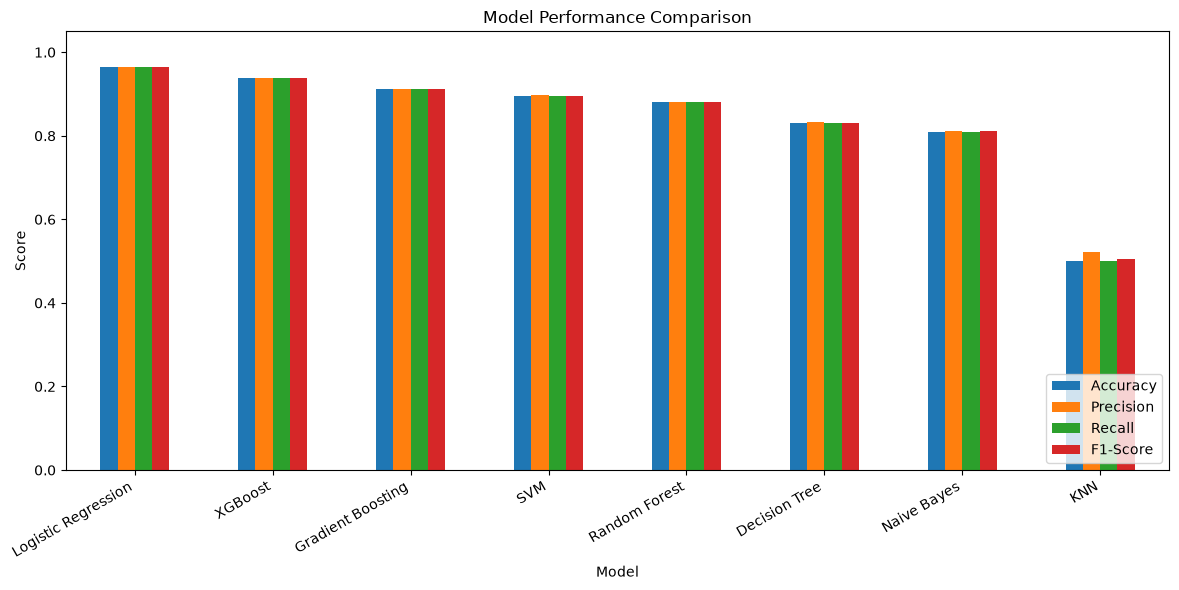

In [24]:
# Visual comparison
plot_df = results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-Score"]]

ax = plot_df.plot(kind="bar", figsize=(12, 6))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=30, ha="right")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 5. Random Forest evaluation

The README specifies Random Forest as the main model. We therefore evaluate the Random Forest model in detail and save it as:

`models/mobile_price_model.pkl`

In [25]:
rf_model = trained_models["Random Forest"]
rf_pred = rf_model.predict(X_test)

print("Random Forest Classification Report:")
print(classification_report(
    y_test,
    rf_pred,
    target_names=["Low Price", "Medium Price", "High Price", "Very High Price"],
    zero_division=0
))

Random Forest Classification Report:
                 precision    recall  f1-score   support

      Low Price       0.94      0.95      0.95       100
   Medium Price       0.80      0.82      0.81       100
     High Price       0.82      0.81      0.81       100
Very High Price       0.96      0.94      0.95       100

       accuracy                           0.88       400
      macro avg       0.88      0.88      0.88       400
   weighted avg       0.88      0.88      0.88       400



In [26]:
# Random Forest metrics
rf_metrics = {
    "Accuracy": accuracy_score(y_test, rf_pred),
    "Precision": precision_score(y_test, rf_pred, average="weighted", zero_division=0),
    "Recall": recall_score(y_test, rf_pred, average="weighted", zero_division=0),
    "F1-Score": f1_score(y_test, rf_pred, average="weighted", zero_division=0)
}

display(pd.DataFrame([rf_metrics]))

,Accuracy,Precision,Recall,F1-Score
0,0.88,0.88047,0.88,0.88018


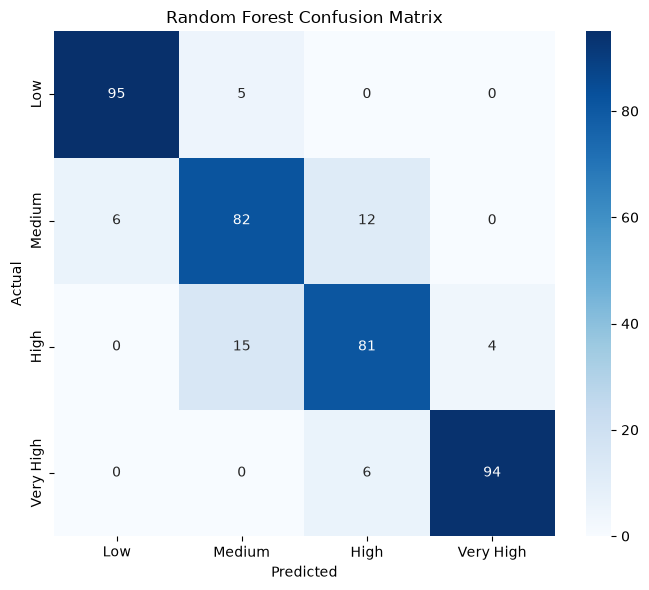

In [27]:
# Confusion matrix
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Low", "Medium", "High", "Very High"],
    yticklabels=["Low", "Medium", "High", "Very High"]
)
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

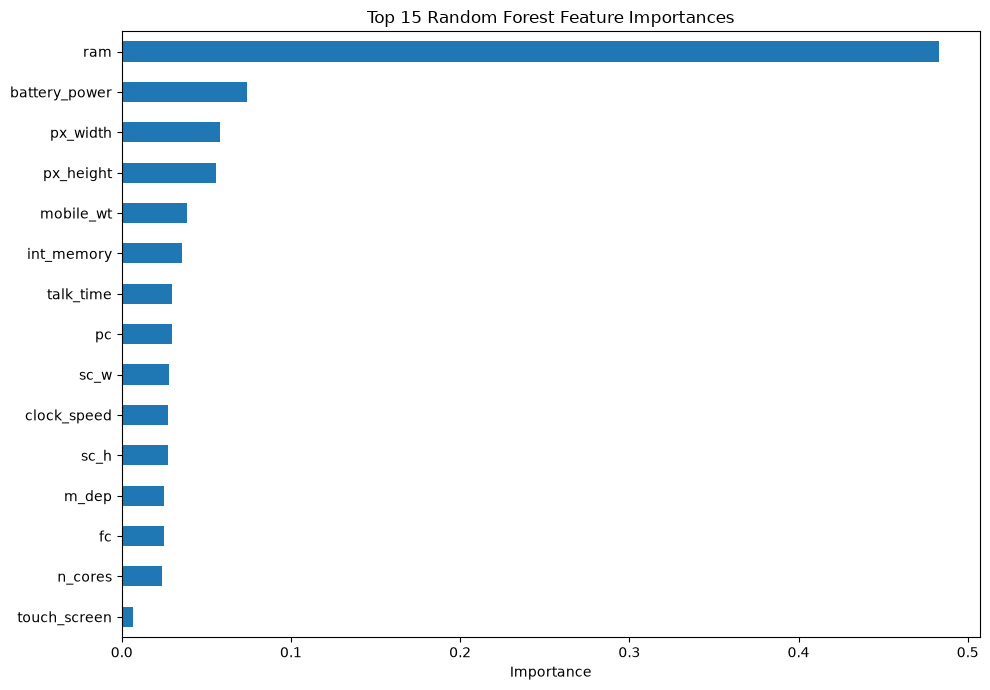

,importance
ram,0.483102
battery_power,0.074234
px_width,0.057801
px_height,0.055615
mobile_wt,0.038501
int_memory,0.035762
talk_time,0.029916
pc,0.029594
sc_w,0.027995
clock_speed,0.027190


In [28]:
# Feature importance
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 7))
feature_importance.head(15).sort_values().plot(kind="barh")
plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

display(feature_importance.to_frame("importance"))

## 6. Save the Random Forest model

The project README specifies `models/mobile_price_model.pkl` as the saved model.

In [29]:
MODEL_PATH = os.path.join(MODEL_DIR, "mobile_price_model.pkl")

joblib.dump(rf_model, MODEL_PATH)

print("Model saved successfully:")
print(MODEL_PATH)
print("File size:", round(os.path.getsize(MODEL_PATH) / 1024, 2), "KB")

Model saved successfully:
C:\Users\vecha\OneDrive\Desktop\Mobile_price_prediction\models\mobile_price_model.pkl
File size: 16054.68 KB


## 7. Generate prediction results

Actual and predicted price ranges are saved to:

`outputs/predictions.csv`

In [30]:
prediction_output = pd.DataFrame({
    "Actual": y_test.reset_index(drop=True),
    "Predicted": pd.Series(rf_pred)
})

PREDICTIONS_PATH = os.path.join(OUTPUT_DIR, "predictions.csv")
prediction_output.to_csv(PREDICTIONS_PATH, index=False)

print("Predictions saved to:", PREDICTIONS_PATH)
display(prediction_output.head(20))

Predictions saved to: C:\Users\vecha\OneDrive\Desktop\Mobile_price_prediction\outputs\predictions.csv


,Actual,Predicted
0,3,3
1,1,1
2,0,0
3,2,1
4,3,3
5,2,2
6,0,0
7,0,0
8,1,1
9,0,0


## 8. Save the model evaluation report

A text report is created at:

`report/model_report.txt`

In [31]:
REPORT_PATH = os.path.join(REPORT_DIR, "model_report.txt")

report_text = classification_report(
    y_test,
    rf_pred,
    target_names=["Low Price", "Medium Price", "High Price", "Very High Price"],
    zero_division=0
)

with open(REPORT_PATH, "w", encoding="utf-8") as f:
    f.write("Mobile Price Prediction - Random Forest Model Report\n")
    f.write("=" * 60 + "\n\n")
    f.write(f"Accuracy : {rf_metrics['Accuracy']:.4f}\n")
    f.write(f"Precision: {rf_metrics['Precision']:.4f}\n")
    f.write(f"Recall   : {rf_metrics['Recall']:.4f}\n")
    f.write(f"F1-Score : {rf_metrics['F1-Score']:.4f}\n\n")
    f.write("Classification Report\n")
    f.write("-" * 60 + "\n")
    f.write(report_text)

print("Report saved to:", REPORT_PATH)

Report saved to: C:\Users\vecha\OneDrive\Desktop\Mobile_price_prediction\reports\model_report.txt


## 9. Load the saved model and predict a new mobile

Enter the mobile specifications in the dictionary below. The feature names must match the training dataset columns.

In [32]:
# Load saved model
loaded_model = joblib.load(MODEL_PATH)

# Example: use the first test row as a safe demonstration input.
sample_input = X_test.iloc[[0]].copy()

sample_prediction = loaded_model.predict(sample_input)[0]

price_labels = {
    0: "Low Price",
    1: "Medium Price",
    2: "High Price",
    3: "Very High Price"
}

print("Predicted class:", sample_prediction)
print("Predicted price range:", price_labels.get(int(sample_prediction), "Unknown"))
print("Actual class:", int(y_test.iloc[0]))
print("Actual price range:", price_labels.get(int(y_test.iloc[0]), "Unknown"))

Predicted class: 3
Predicted price range: Very High Price
Actual class: 3
Actual price range: Very High Price


## 10. Final project outputs

After running all cells, the important generated files are:

- `models/mobile_price_model.pkl` — trained Random Forest model
- `outputs/predictions.csv` — actual vs predicted values
- `report/model_report.txt` — evaluation report

These paths match the project structure described in the uploaded README.

In [33]:
# Final verification
for path in [MODEL_PATH, PREDICTIONS_PATH, REPORT_PATH]:
    print(f"{path}: {'EXISTS' if os.path.exists(path) else 'MISSING'}")

C:\Users\vecha\OneDrive\Desktop\Mobile_price_prediction\models\mobile_price_model.pkl: EXISTS
C:\Users\vecha\OneDrive\Desktop\Mobile_price_prediction\outputs\predictions.csv: EXISTS
C:\Users\vecha\OneDrive\Desktop\Mobile_price_prediction\reports\model_report.txt: EXISTS
